In [19]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [20]:
X,y=make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20)

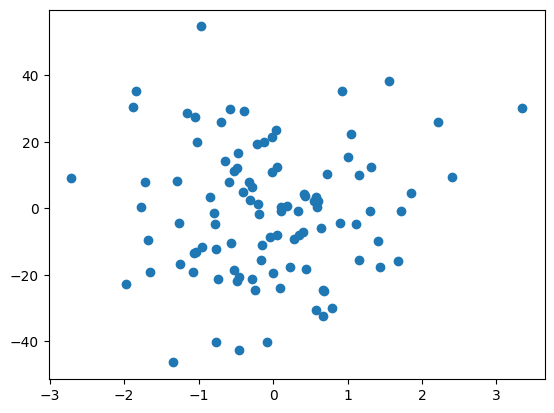

In [21]:
plt.scatter(X,y)

In [40]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [41]:
from sklearn.linear_model import LinearRegression

In [42]:
lr=LinearRegression()

In [43]:
lr.fit(X_train,y_train)

LinearRegression()

In [44]:
print(lr.coef_)
print(lr.intercept_)

[1.92942681]
-1.5363350368161548


In [45]:
y_pred=lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

-0.12066017687242758

In [46]:
np.mean(cross_val_score(lr,X,y,scoring="r2",cv=10))

np.float64(-0.15648698255668025)

In [47]:
class GDRegressor:
  def __init__(self,learning_rate,epochs):
    self.m=100
    self.b=-120
    self.lr=learning_rate
    self.epochs=epochs
  def fit(self,X,y):
    #calculate b using gradient descent
    for i in range(self.epochs):
      loss_slope_b=-2*np.sum(y-self.m*X.ravel()-self.b)
      loss_slope_m=-2*np.sum((y-self.m*X.ravel()-self.b)*X.ravel())
      self.b=self.b-(self.lr*loss_slope_b)
      self.m=self.m-(self.lr*loss_slope_m)
    print(self.m,self.b)

  def predict(self,X):
    return self.m*X+self.b

In [48]:
gd=GDRegressor(0.001,100)

In [49]:
gd.fit(X_train,y_train)

1.9294264253507238 -1.5363377343265299


In [35]:
gd.predict(X)

array([[-1.30577198],
       [-2.76800089],
       [-1.22155915],
       [-0.35773537],
       [-1.83622248],
       [-1.40062882],
       [-0.32287751],
       [ 1.04464723],
       [-0.18200708],
       [-1.12288843],
       [ 0.20350846],
       [-1.41297016],
       [ 0.44643025],
       [-1.48449828],
       [ 0.62132366],
       [-0.07253011],
       [-0.93096723],
       [-0.73913207],
       [-1.93199477],
       [-0.73625738],
       [ 0.6066093 ],
       [-0.10070759],
       [ 0.87011006],
       [ 0.40536843],
       [-0.75522664],
       [-1.91555755],
       [-1.1029144 ],
       [-1.01372675],
       [ 0.05322611],
       [-1.6306046 ],
       [-2.14134076],
       [-1.43469724],
       [-2.15724971],
       [-2.04162166],
       [-0.43836405],
       [-0.41945192],
       [ 1.19054846],
       [-1.31432875],
       [ 1.00191169],
       [-1.06248456],
       [-0.97256737],
       [-1.27910571],
       [-0.80192244],
       [-0.68816617],
       [-0.34614915],
       [ 1

In [50]:
y_pred=gd.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

-0.12066025114567691